In [61]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import matplotlib.pylab as pltb
from sklearn.model_selection import train_test_split

In [62]:
df = pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [63]:
df.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'survived'],
      dtype='str')

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.isnull().sum()

pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64

In [66]:
df.corr(numeric_only=True)

,pclass,age,sibsp,parch,fare,survived
pclass,1.000000,-0.408106,0.060832,0.018322,-0.558629,-0.312469
age,-0.408106,1.000000,-0.243699,-0.150917,0.178739,-0.055513
sibsp,0.060832,-0.243699,1.000000,0.373587,0.160238,-0.027825
parch,0.018322,-0.150917,0.373587,1.000000,0.221539,0.082660
fare,-0.558629,0.178739,0.160238,0.221539,1.000000,0.244265
survived,-0.312469,-0.055513,-0.027825,0.082660,0.244265,1.000000


In [67]:
df.nunique()

pclass         3
name        1307
sex            2
age           98
sibsp          7
parch          8
ticket       929
fare         281
cabin        186
embarked       3
survived       2
dtype: int64

In [68]:
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [69]:
x = df.drop(columns=['survived','cabin','ticket','name'])
y = df['survived']

In [70]:
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [71]:
num_col = x.select_dtypes(include='number').columns
cat_col = x.select_dtypes(include='object').columns

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9544\1161364473.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = x.select_dtypes(include='object').columns


In [72]:
df.describe()

,pclass,age,sibsp,parch,fare,survived
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,0.381971
std,0.837836,14.413500,1.041658,0.865560,51.758668,0.486055
min,1.000000,0.166700,0.000000,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


In [73]:
xtrain,xtest,ytarin,ytest = train_test_split(x,y,train_size=0.7,random_state=42)

In [74]:
x.isnull().sum()

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

In [75]:
x

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,14.4542,C
1305,3,female,NaN,1,0,14.4542,C
1306,3,male,26.5000,0,0,7.2250,C
1307,3,male,27.0000,0,0,7.2250,C


In [76]:
xtrain.isnull().sum()

pclass        0
sex           0
age         187
sibsp         0
parch         0
fare          1
embarked      1
dtype: int64

In [77]:
from sklearn.impute import SimpleImputer

num_impute = SimpleImputer(strategy='mean')
xtrain[['age','fare']] = num_impute.fit_transform(xtrain[['age','fare']])
xtest[['age','fare']] = num_impute.transform(xtest[['age','fare']])

cat_impute = SimpleImputer(strategy='most_frequent')
xtrain[['embarked']] = cat_impute.fit_transform(xtrain[['embarked']])
xtest[['embarked']] = cat_impute.transform(xtest[['embarked']])


In [78]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

preprpcessing = ColumnTransformer(
                                transformers=[
                                            ('scaling',StandardScaler(),num_col),
                                            ('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_col)
                                            ],remainder='passthrough')

preprpcessing.fit_transform(xtrain)
preprpcessing.transform(xtest)

# dont give same column for diff pre processign

array([[ 8.25247782e-01,  4.77070959e-01, -4.98615607e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.25247782e-01, -7.36296180e-01,  4.25942887e-01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.25247782e-01, -2.87383069e-16, -4.98615607e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       ...,
       [-3.63316634e-01,  9.62417815e-01, -4.98615607e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.25247782e-01, -2.87383069e-16, -4.98615607e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-3.63316634e-01, -1.22164304e+00,  4.25942887e-01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(393, 10))

In [79]:
print(type(xtrain))

<class 'pandas.DataFrame'>


In [80]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# xtrain_smote,ytarin_smote = smote.fit_resample(xtrain,ytarin)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
mainpine = Pipeline(
                    steps=[
                        ('preprpcessing',preprpcessing),
                        ('model',LogisticRegression())
                    ])
mainpine.fit(xtrain,ytarin) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprpcessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [82]:
from sklearn.metrics import classification_report

print('LogisticRegression')

xtest_predict = mainpine.predict(xtest)
print(classification_report(ytest,xtest_predict))

LogisticRegression
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       224
           1       0.84      0.67      0.75       169

    accuracy                           0.80       393
   macro avg       0.81      0.79      0.79       393
weighted avg       0.81      0.80      0.80       393



In [83]:
print("train: ",mainpine.score(xtrain,ytarin))
print("test: ",mainpine.score(xtest,ytest))


train:  0.7958515283842795
test:  0.8040712468193384


In [84]:
from sklearn.naive_bayes import GaussianNB

PipelineNB = Pipeline(
                    steps=[
                          ('preprpcessing',preprpcessing),
                          ('model',GaussianNB())
                    ])

PipelineNB.fit(xtrain,ytarin)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprpcessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [85]:
xtest_pre = PipelineNB.predict(xtest)

In [86]:
print('Gaussian Navybaise')
print(classification_report(ytest,xtest_pre),end='\n\n')
print('Train :',PipelineNB.score(xtrain,ytarin))
print('Test :',PipelineNB.score(xtest,ytest))


Gaussian Navybaise
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       224
           1       0.76      0.73      0.74       169

    accuracy                           0.78       393
   macro avg       0.78      0.78      0.78       393
weighted avg       0.78      0.78      0.78       393


Train : 0.7816593886462883
Test : 0.7837150127226463


In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

PipelineGT = Pipeline(
                    steps=[
                          ('preprpcessing',preprpcessing),
                        #   ('PCA',PCA(n_components=0.95)),
                          ('model',DecisionTreeClassifier())
                    ])

PipelineGT.fit(xtrain,ytarin)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprpcessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [88]:
xtest_pre = PipelineNB.predict(xtest)

print('Descion Ttree')
print(classification_report(ytest,xtest_pre),end='\n\n')
print('Train :',PipelineGT.score(xtrain,ytarin))
print('Test :',PipelineGT.score(xtest,ytest))


Descion Ttree
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       224
           1       0.76      0.73      0.74       169

    accuracy                           0.78       393
   macro avg       0.78      0.78      0.78       393
weighted avg       0.78      0.78      0.78       393


Train : 0.972707423580786
Test : 0.732824427480916


In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

grid = GridSearchCV(
               estimator=PipelineGT,
               param_grid = {
                            'model__criterion': ['gini', 'entropy', 'log_loss'],
                            'model__splitter': ['best', 'random'],
                            'model__max_depth': [None, 3, 5, 7,10],
                            'model__min_samples_split': [2, 5, 10],
                            'model__min_samples_leaf': [1, 2, 4],
                            'model__max_features': [None, 'sqrt', 'log2']
                            },
                n_jobs=-1,
                verbose=10,
                cv=5,
                scoring='accuracy')
grid.fit(xtrain,ytarin)


Fitting 5 folds for each of 810 candidates, totalling 4050 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [None, 3, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [90]:
print(grid.best_params_)
print(grid.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__splitter': 'random'}
0.8122416250890947


In [91]:
from sklearn.metrics import classification_report

best_model = grid.best_estimator_

xtest_pre = best_model.predict(xtest)
print(classification_report(ytest,xtest_pre),end='\n\n')
print('Train :',best_model.score(xtrain,ytarin))
print('Test :',best_model.score(xtest,ytest))





              precision    recall  f1-score   support

           0       0.74      0.94      0.83       224
           1       0.88      0.57      0.69       169

    accuracy                           0.78       393
   macro avg       0.81      0.76      0.76       393
weighted avg       0.80      0.78      0.77       393


Train : 0.8089519650655022
Test : 0.7811704834605598


              feature  Importance
6    encode__sex_male    0.648814
0     scaling__pclass    0.291646
7  encode__embarked_C    0.029768
9  encode__embarked_S    0.026186
1        scaling__age    0.003586
2      scaling__sibsp    0.000000
5  encode__sex_female    0.000000
4       scaling__fare    0.000000
3      scaling__parch    0.000000
8  encode__embarked_Q    0.000000


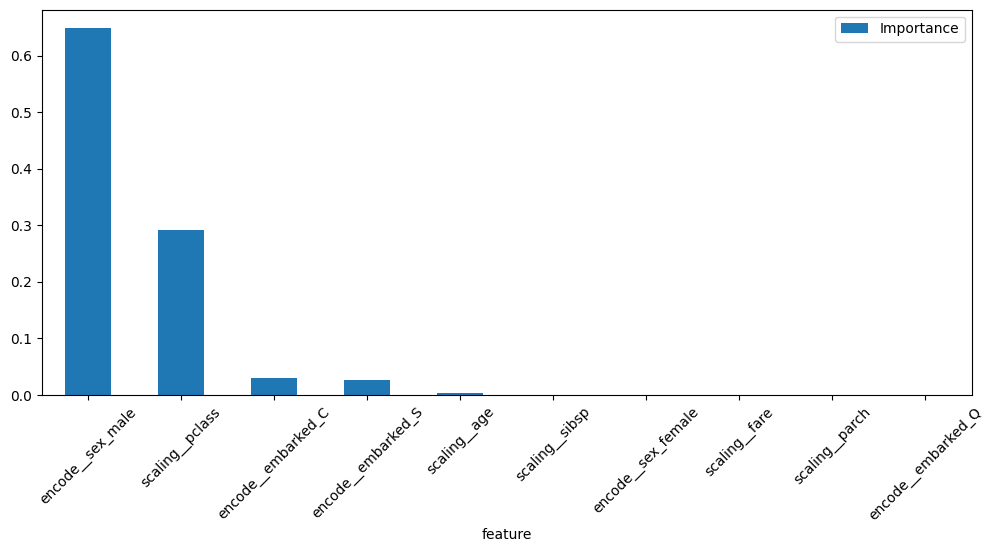

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = best_model.named_steps['model'].feature_importances_

feature_name = best_model.named_steps['preprpcessing'].get_feature_names_out()


importance = pd.DataFrame({
    'feature':feature_name,
    "Importance": feature_importance,
})

importance = importance.sort_values("Importance", ascending=False)

print(importance)

importance.plot(
    x='feature',
    y='Importance',
    kind='bar',
    figsize=(12,5)
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib as plt

corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True
)
plt.show()

AttributeError: module 'matplotlib' has no attribute 'show'

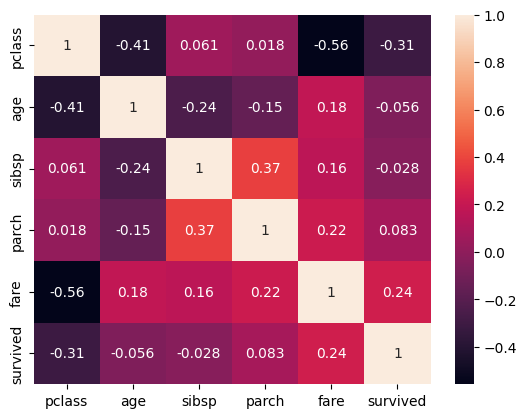

In [104]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True
)
plt.show()

In [93]:
print(len(xtrain.columns))
print(len(feature_importance))

7
10
